# 정적분으로 정의된 함수

$$
F(x) = \int_a^x f(t)\, dt
$$

이면 ( $f$가 연속일 때 ) **미적분학의 기본정리(FTC)**:

$$
F'(x) = f(x)
$$

## 1. $F(x)$를 닫힌 형태로

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x, t = sp.symbols('x t')

a = 0
f = t**2 + 3*t + 2

F = sp.integrate(f, (t, a, x))
print("f(t) =")
display(f)
print("F(x) = ∫₀ˣ f(t) dt =")
display(F)

f(t) =


F(x) = ∫₀ˣ f(t) dt =


**상한이 변수**: <br>
=> `sp.integrate(f, (t, a, x))` → $x$의 함수

**하한·상한 교환**: <br>
=> $\int_x^a f = -\int_a^x f$

## 2. FTC 검산: $F'=f$

In [7]:
dF = sp.diff(F, x)
f_of_x = f.subs(t, x)

print("F'(x) =")
display(dF)
print("f(x) =")
display(f_of_x)
print("F' == f ?", sp.simplify(dF - f_of_x) == 0)

F'(x) =


f(x) =


F' == f ? True


## 3. $G(x)-G(a)$ 형태

In [8]:
G = sp.integrate(f, t)  # 부정적분
F2 = sp.simplify(G.subs(t, x) - G.subs(t, a))

print("G(t) =")
display(G)
print("G(x)-G(a) =")
display(F2)
print("앞의 F와 같나?", sp.simplify(F - F2) == 0)

G(t) =


G(x)-G(a) =


앞의 F와 같나? True


## 5. 그래프: $f$와 $F$

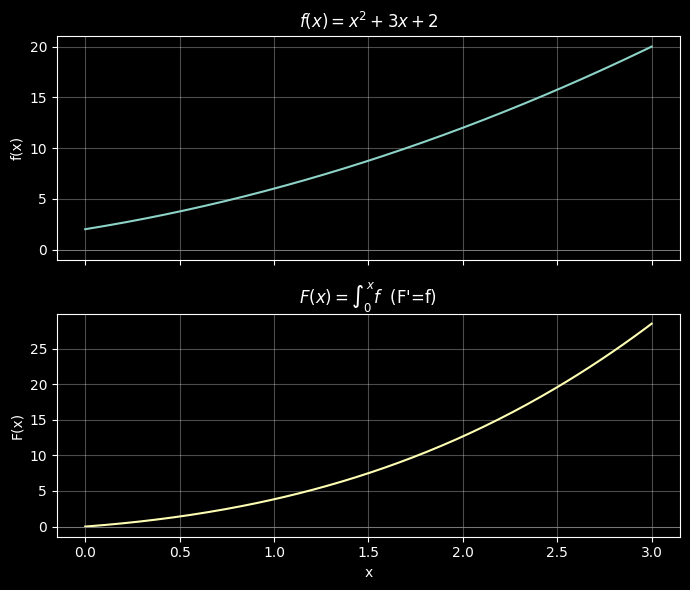

In [9]:
f_x = f.subs(t, x)
f_num = sp.lambdify(x, f_x, 'numpy')
F_num = sp.lambdify(x, F, 'numpy')

xs = np.linspace(0, 3, 200)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].plot(xs, f_num(xs), color="C0")
axes[0].set_ylabel("f(x)")
axes[0].axhline(0, color="gray", lw=0.6)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(r"$f(x)=x^2+3x+2$")

axes[1].plot(xs, F_num(xs), color="C1")
axes[1].set_ylabel("F(x)")
axes[1].set_xlabel("x")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].grid(True, alpha=0.3)
axes[1].set_title(r"$F(x)=\int_0^x f$  (F'=f)")
plt.tight_layout()
plt.show()